# Load and Explore the Dataset:
<p>The objective of this task is to load and examine the Breast Cancer Wisconsin dataset from sklearn.datasets and gain a clear understanding of its structure and features. </p><p>Begin by importing the dataset using <code><strong>load_breast_cancer()</strong></code> and converting it into a structured tabular format using pandas DataFrame for better interpretability. The dataset contains multiple medical features computed from digitized images of breast mass samples, along with a binary target variable indicating whether the tumor is malignant or benign. </p><p>Once the dataset is loaded, inspect its dimensions by checking the shape of the feature matrix and target vector. Additionally, display the first few rows of the dataset to understand feature names, data types, and overall structure. This step helps establish a foundational understanding of the dataset before proceeding to preprocessing, feature scaling, and model development.</p>


In [10]:
# Importing Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

import tensorflow as tf
from tensorflow import keras

import warnings
warnings.filterwarnings("ignore")

In [11]:
# Loading and Understanding the Breast Cancer Dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Dataset Shape: (569, 30)

Class Distribution:
1    357
0    212
Name: count, dtype: int64


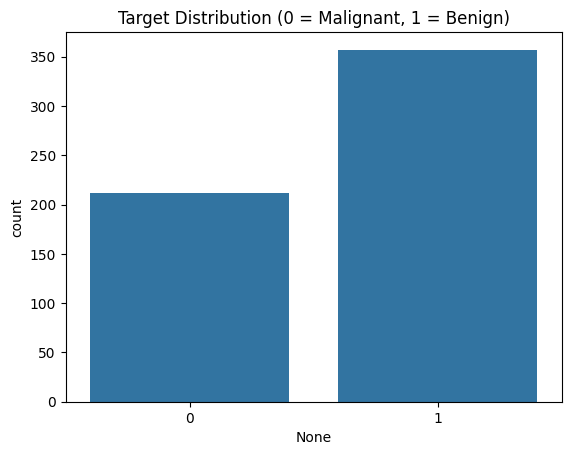

In [12]:
# Exploring Dataset Structure and Features
print("Dataset Shape:", X.shape)
print("\nClass Distribution:")
print(y.value_counts())

sns.countplot(x=y)
plt.title("Target Distribution (0 = Malignant, 1 = Benign)")
plt.show()

In [13]:
# Splitting the Dataset into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
# Feature Scaling and Data Preprocessing
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<p>Before training a deep learning model, a Logistic Regression classifier is used as a baseline model.

This helps compare:
- Traditional machine learning performance
- Deep learning performance

The baseline model provides a simple benchmark for classification accuracy.</p>

In [15]:
# Logistic Regression
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.9824561403508771
Random Forest Accuracy: 0.956140350877193



# Designing and Training a Neural Network for Classification
<p>A deep learning model is constructed using TensorFlow/Keras.

The neural network consists of:
- Input layer
- Hidden dense layers with activation functions
- Output layer for binary classification

The model is compiled with:
- Optimizer
- Loss function
- Evaluation metrics

After compilation, the model is trained on the scaled training dataset.</p>

In [16]:
# Building a Neural Network for Breast Cancer Classification
model = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.8187 - loss: 0.5085 - val_accuracy: 0.9231 - val_loss: 0.3836
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9588 - loss: 0.3037 - val_accuracy: 0.9560 - val_loss: 0.2298
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9615 - loss: 0.1841 - val_accuracy: 0.9560 - val_loss: 0.1508
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9725 - loss: 0.1278 - val_accuracy: 0.9560 - val_loss: 0.1113
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9863 - loss: 0.1002 - val_accuracy: 0.9780 - val_loss: 0.0902
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9863 - loss: 0.0849 - val_accuracy: 0.9780 - val_loss: 0.0752
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9863 - loss: 0.0748 - val_accuracy: 0.9780 - val_loss: 0.0673
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9863 - loss: 0.0684 - val_accuracy: 0.9780 - val

In [17]:
# Generating Predictions and Evaluating Model Performance
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Neural Network Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Neural Network Accuracy: 0.956140350877193
Precision: 0.9855072463768116
Recall: 0.9444444444444444
F1 Score: 0.9645390070921985
ROC-AUC: 0.9920634920634921


A confusion matrix is generated to analyze prediction performance in detail.

The confusion matrix helps identify:
- Correct predictions
- False positives
- False negatives

This provides deeper insight into how well the classifier distinguishes between malignant and benign tumors.

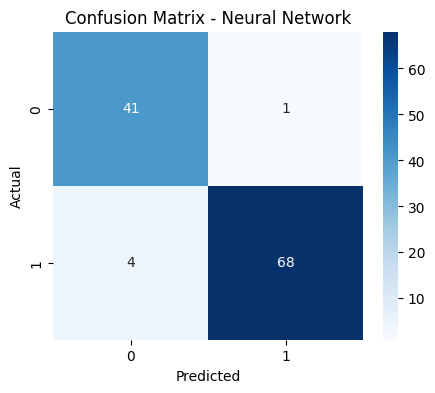

In [18]:
# Confusion Matrix and Classification Analysis
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
# Comparing Predicted Results
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Neural Network"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, y_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.982456
1,Random Forest,0.956140
2,Neural Network,0.956140
